## Environment (use a T4 session)

In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec('timm') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'timm', '--no-deps'])
import timm, torch
print('timm', timm.__version__, '| torch', torch.__version__, '| cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    try:
        _ = (torch.zeros(1, 3, 4, 4, device='cuda') * 2).sum().item(); print('GPU kernel check: OK')
    except RuntimeError:
        print('GPU kernel check FAILED -> switch accelerator to GPU T4 x2, then rerun.'); raise

timm 1.0.26 | torch 2.10.0+cu128 | cuda: True
GPU kernel check: OK


## Config

In [ ]:
import os, torch, random, numpy as np
# ---- Carmack paths (persistent /scratch) ----
SCRATCH   = '/scratch/ttran72'
DATA_DIR  = f'{SCRATCH}/datasets/viet-medi-species-2026'   # ImageFolder root: one subfolder per class
CKPT_DIR  = f'{SCRATCH}/checkpoints'                        # checkpoints, .pt/.onnx, history, results json
CACHE_DIR = f'{SCRATCH}/cache'                              # split cache
LOG_DIR   = f'{SCRATCH}/logs'
for _d in (CKPT_DIR, CACHE_DIR, LOG_DIR): os.makedirs(_d, exist_ok=True)
# ---------------------------------------------
MODEL_NAMES  = ['vit_base_patch16_224']
INPUT_SIZE   = 224
BATCH_SIZE   = 32     # reduce (e.g. 16) if you hit CUDA OOM
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.15    # held-out test set; final reported metrics come from here
MIN_IMAGES_PER_CLASS = 25   # matches the >=25 filter (2,719 classes) used in the IoT paper
EPOCHS       = int(os.environ.get('EPOCHS', '80'))   # high cap; early stopping (PATIENCE) decides the real stop -> a CONVERGED ceiling
LR           = 3e-05
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS   = 2
LABEL_SMOOTHING = 0.1
PATIENCE     = 7        # early-stop patience (epochs without Top-1 gain); now persisted across resumes
TOPK_WANTED  = [1, 5, 10]
NUM_WORKERS  = 8   # Carmack: real multi-core node; raise if GPU-starved, lower if RAM-bound
USE_AMP      = True
BALANCED_SAMPLER = False
RESUME       = True
SEED         = int(os.environ.get('SEED', '42'))     # matched per-seed to Notebook 2 (same split)
VIT_CEILING = None   # this notebook produces it
EXPORT_SOFT_LABELS = False

# ---- Cesar's feature-highlighting preprocessing (MUST match Notebook 2 for a fair comparison) ----
# Set per run from the shell:  PREP=clahe SEED=42 jupyter nbconvert ...  (same driver as Notebook 2)
PREPROCESS      = os.environ.get('PREP', 'baseline')   # 'baseline' | 'clahe' | 'sobel' | 'clahe_sobel'  (same env var as Notebook 2 / run_grid.sh)
SOURCE_DOWNSCALE = 1.0
assert PREPROCESS in ('baseline', 'clahe', 'sobel', 'clahe_sobel'), f'bad PREPROCESS={PREPROCESS!r}'
# -------------------------------------------------------------------------------------------------

RUN_TAG = PREPROCESS + ('' if SOURCE_DOWNSCALE == 1.0 else f'_ds{SOURCE_DOWNSCALE}') + f'_s{SEED}'
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device, '| preprocess:', PREPROCESS, '| seed:', SEED, '| epochs cap:', EPOCHS, '| run tag:', RUN_TAG)
print('results file will be:', os.path.join(CKPT_DIR, f'vit_results_{RUN_TAG}.json'), '(distinct from Notebook 2)')
if os.path.isdir(DATA_DIR):
    _n = sum(1 for e in os.scandir(DATA_DIR) if e.is_dir())
    print(f'DATA_DIR OK: {DATA_DIR}  ({_n} class folders)')
else:
    print(f'DATA_DIR MISSING: {DATA_DIR}  -> download the dataset into scratch first')

## Resume seed (for chained background commits)

In [ ]:
# On Carmack, /scratch persists between runs, so the Kaggle "seed working dir from
# a previous commit's input" step is unnecessary - RESUME reads checkpoints straight
# from CKPT_DIR. Kept as a guarded no-op so cell numbering matches the paper.
import glob, os
RESUME_FROM = None   # normally leave None on Carmack
if RESUME_FROM:
    import shutil
    for pat in ('*_ckpt.pt', 'split_cache_*.pkl'):
        for f in glob.glob(os.path.join(RESUME_FROM, pat)):
            dst = os.path.join(CKPT_DIR, os.path.basename(f))
            if not os.path.exists(dst):
                shutil.copy(f, dst); print('seeded', os.path.basename(f))
print('RESUME reads checkpoints from', CKPT_DIR)

In [4]:
import os, math, time, copy, random
from collections import Counter
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.amp import autocast, GradScaler
from torchvision import datasets, transforms as T
from PIL import Image
from timm.data import resolve_model_data_config, create_transform

## Cesar's preprocessing transform\n\nIdentical to Notebook 2. PIL RGB in -> PIL RGB out, prepended to timm's pipeline. `'baseline'` + `SOURCE_DOWNSCALE=1.0` is a no-op.

In [5]:
import cv2

class CesarPreprocess:
    """Feature-highlighting preprocessing. PIL RGB in -> PIL RGB out."""
    def __init__(self, mode='baseline', downscale=1.0):
        self.mode, self.downscale = mode, downscale

    def __call__(self, img):
        arr = np.asarray(img.convert('RGB'))  # HWC RGB uint8
        if self.downscale and self.downscale != 1.0:
            h, w = arr.shape[:2]
            arr = cv2.resize(arr, (max(1, int(w * self.downscale)), max(1, int(h * self.downscale))),
                             interpolation=cv2.INTER_AREA)
        if self.mode in ('clahe', 'clahe_sobel'):
            lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            l = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
            arr = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
        if self.mode in ('sobel', 'clahe_sobel'):
            gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
            gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
            gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
            mag = cv2.magnitude(gx, gy)
            mag = np.clip(mag / (mag.max() + 1e-6) * 255.0, 0, 255).astype(np.uint8)
            if self.mode == 'sobel':
                arr = cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)          # pure edge map
            else:
                edges = cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)
                arr = cv2.addWeighted(arr, 0.7, edges, 0.3, 0.0)     # contrast + shape
        return Image.fromarray(arr)

def build_transforms(dc, mode, downscale):
    train_tf = create_transform(**dc, is_training=True)
    eval_tf  = create_transform(**dc, is_training=False)
    if mode == 'baseline' and (downscale in (None, 1.0)):
        return train_tf, eval_tf                       # exact original pipeline
    pre = CesarPreprocess(mode=mode, downscale=downscale)
    return T.Compose([pre, *train_tf.transforms]), T.Compose([pre, *eval_tf.transforms])

In [6]:
from sklearn.metrics import f1_score

class PlantDS(Dataset):
    def __init__(self, samples, tf): self.samples, self.tf = samples, tf
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, y = self.samples[i]
        return self.tf(Image.open(path).convert('RGB')), y

def filter_min_images(samples, class_names, min_n):
    """Keep only classes with >= min_n images; relabel kept classes to 0..C-1."""
    counts = Counter(y for _, y in samples)
    keep = sorted(y for y, c in counts.items() if c >= min_n)
    remap = {old: new for new, old in enumerate(keep)}
    new_samples = [(p, remap[y]) for p, y in samples if y in remap]
    new_class_names = [class_names[y] for y in keep]
    return new_samples, new_class_names

def stratified_split_3way(samples, val_split, test_split, seed):
    """Per-class stratified train/val/test. Every class contributes to all three
    splits (guaranteed >=1 train sample), so val/test cover the full class set."""
    by = {}
    for i, (p, y) in enumerate(samples):
        by.setdefault(y, []).append(i)
    rng = random.Random(seed); tr, va, te = [], [], []
    for y, ids in by.items():
        rng.shuffle(ids); n = len(ids)
        n_test = max(1, int(round(n * test_split)))
        n_val  = max(1, int(round(n * val_split)))
        if n_test + n_val >= n:                      # keep >=1 for training
            n_test = min(n_test, max(1, n - 2))
            n_val  = max(1, n - n_test - 1)
        te += ids[:n_test]; va += ids[n_test:n_test + n_val]; tr += ids[n_test + n_val:]
    pick = lambda idx: [samples[i] for i in idx]
    return pick(tr), pick(va), pick(te)

def topk_hits(logits, y, ks):
    top = logits.topk(max(ks), 1).indices
    correct = (top == y.unsqueeze(1))
    return {k: correct[:, :k].any(1).float().sum().item() for k in ks}

def make_loaders(train_s, val_s, train_tf, eval_tf, batch, workers, balanced):
    if balanced:
        counts = Counter(y for _, y in train_s)
        w = [1.0 / counts[y] for _, y in train_s]
        sampler = WeightedRandomSampler(w, num_samples=len(train_s), replacement=True)
        tl = DataLoader(PlantDS(train_s, train_tf), batch_size=batch, sampler=sampler,
                        num_workers=workers, pin_memory=True, persistent_workers=workers > 0)
    else:
        tl = DataLoader(PlantDS(train_s, train_tf), batch_size=batch, shuffle=True,
                        num_workers=workers, pin_memory=True, persistent_workers=workers > 0)
    vl = DataLoader(PlantDS(val_s, eval_tf), batch_size=batch, shuffle=False,
                    num_workers=workers, pin_memory=True, persistent_workers=workers > 0)
    return tl, vl

def make_eval_loader(samples, tf, batch, workers):
    return DataLoader(PlantDS(samples, tf), batch_size=batch, shuffle=False,
                      num_workers=workers, pin_memory=True, persistent_workers=workers > 0)

@torch.no_grad()
def evaluate(model, loader, ks, device, amp):
    """Final held-out evaluation: Top-k accuracy + macro/weighted F1 (top-1)."""
    model = model.to(device).eval()
    hits = {k: 0 for k in ks}; n = 0; y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        with autocast('cuda', enabled=amp, dtype=torch.float16):
            logits = model(x).float().cpu()
        top = logits.topk(max(ks), 1).indices
        correct = (top == y.unsqueeze(1))
        for k in ks: hits[k] += correct[:, :k].any(1).float().sum().item()
        n += y.size(0)
        y_true.append(y.numpy()); y_pred.append(top[:, 0].numpy())
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    accs = {k: hits[k] / n for k in ks}
    return {'accs': accs, 'n': int(n),
            'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
            'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0))}

def cosine_warmup(opt, warmup_steps, total_steps):
    def f(step):
        if step < warmup_steps:
            return (step + 1) / max(1, warmup_steps)
        p = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * min(1.0, p)))
    return torch.optim.lr_scheduler.LambdaLR(opt, f)


In [7]:
def train_one(model, name, train_s, val_s, train_tf, eval_tf, cfg):
    device = cfg['device']
    print(f'  building dataloaders (workers={cfg["workers"]}) ...', flush=True)
    tl, vl = make_loaders(train_s, val_s, train_tf, eval_tf,
                          cfg['batch'], cfg['workers'], cfg['balanced'])
    print('  dataloaders ready', flush=True)
    for p in model.parameters(): p.requires_grad = True
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['wd'])
    steps = len(tl)
    sched = cosine_warmup(opt, cfg['warmup_ep'] * steps, cfg['epochs'] * steps)
    crit = nn.CrossEntropyLoss(label_smoothing=cfg['label_smooth'])
    scaler = GradScaler('cuda', enabled=cfg['amp'])
    ks = cfg['topk']
    ckpt_path = os.path.join(cfg['ckpt_dir'], f"{name}_{cfg['run_tag']}_ckpt.pt")
    hist_path = os.path.join(cfg['ckpt_dir'], f"{name}_{cfg['run_tag']}_history.csv")
    if not os.path.exists(hist_path):
        with open(hist_path, 'w') as _h:
            _h.write('model,run_tag,seed,epoch,train_loss,' + ','.join(f'val_top{k}' for k in ks) + ',epoch_seconds\n')

    # best_accs snapshots ALL Top-k at the improving epoch (fixes last-epoch reporting bug)
    # patience is persisted so early stopping behaves identically across chained resumes
    best_acc, best_state, best_accs, patience, start = 0.0, None, None, 0, 0
    total_train_s = 0.0
    if cfg['resume'] and os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ck['model']); opt.load_state_dict(ck['opt'])
        sched.load_state_dict(ck['sched']); scaler.load_state_dict(ck['scaler'])
        start = ck['epoch'] + 1; best_acc = ck['best_acc']; best_state = ck['best_state']
        best_accs = ck.get('best_accs'); patience = ck.get('patience', 0)
        total_train_s = ck.get('total_train_s', 0.0)
        print(f'resumed {name} from epoch {start} (best Top-1={best_acc:.3f}, patience={patience})', flush=True)

    print(f'  entering training loop at epoch {start+1}/{cfg["epochs"]} ...', flush=True)
    for ep in range(start, cfg['epochs']):
        model.train(); run = 0.0; t0 = time.time()
        for x, y in tl:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=cfg['amp'], dtype=torch.float16):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            run += loss.item() * x.size(0)
        model.eval(); hits = {k: 0 for k in ks}; n = 0
        with torch.no_grad(), autocast('cuda', enabled=cfg['amp'], dtype=torch.float16):
            for x, y in vl:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                h = topk_hits(model(x).float(), y, ks)
                for k in ks: hits[k] += h[k]
                n += x.size(0)
        accs = {k: hits[k] / n for k in ks}; top1 = accs[ks[0]]
        dt = time.time() - t0
        total_train_s += dt
        with open(hist_path, 'a') as _h:
            _h.write(f"{name},{cfg['run_tag']},{cfg.get('seed','')},{ep+1},{run/len(train_s):.6f},"
                     + ','.join(f'{accs[k]:.6f}' for k in ks) + f',{dt:.2f}\n')
        improved = top1 > best_acc
        if improved:
            best_acc, best_state, patience = top1, copy.deepcopy(model.state_dict()), 0
            best_accs = dict(accs)          # snapshot all Top-k at the best epoch
        else:
            patience += 1
        torch.save({'epoch': ep, 'model': model.state_dict(), 'opt': opt.state_dict(),
                    'sched': sched.state_dict(), 'scaler': scaler.state_dict(),
                    'best_acc': best_acc, 'best_state': best_state,
                    'best_accs': best_accs, 'patience': patience,
                    'total_train_s': total_train_s}, ckpt_path)
        msg = '  '.join(f'top{k}={accs[k]:.3f}' for k in ks)
        star = '  *best*' if improved else ''
        print(f'  epoch {ep+1:2d}/{cfg["epochs"]}  loss={run/len(train_s):.3f}  {msg}  '
              f'({dt:.0f}s/ep, ETA {dt*(cfg["epochs"]-ep-1)/60:.0f}m){star}', flush=True)
        if patience >= cfg['patience']:
            print(f'  early stop: no Top-1 gain for {cfg["patience"]} epochs'); break

    model.load_state_dict(best_state)
    return {'model': model.to('cpu').eval(),
            'params': sum(p.numel() for p in model.parameters()),
            'best_acc': best_acc, 'best_accs': best_accs,
            'runtime_s': total_train_s}   # best-epoch Top-k + train wall-clock

## Read dataset + stratified split

In [ ]:
import pickle, time
# Cache the filtered + split sample lists so chained commits skip the ~15 min
# ImageFolder walk and reuse the EXACT same train/val/test split every run.
# The cache is invalidated automatically if DATA_DIR / filter / split fracs / seed change.
# keyed by SEED (not RUN_TAG) so Notebook 1 and Notebook 2 at the same seed load the
# IDENTICAL split -> the ViT ceiling is measured on the same test set as the mobile models.
cache_path = os.path.join(CACHE_DIR, f'split_cache_s{SEED}.pkl')
_key = dict(data_dir=DATA_DIR, min_imgs=MIN_IMAGES_PER_CLASS,
            val=VAL_SPLIT, test=TEST_SPLIT, seed=SEED)

cache = None
if os.path.exists(cache_path):
    with open(cache_path, 'rb') as f:
        cand = pickle.load(f)
    if cand.get('key') == _key:
        cache = cand
    else:
        print('split cache found but parameters changed -> rebuilding'); print('  cached:', cand.get('key')); print('  now   :', _key)

if cache is not None:
    CLASS_NAMES = cache['class_names']; train_s, val_s, test_s = cache['train'], cache['val'], cache['test']
    NUM_CLASSES = len(CLASS_NAMES)
    TOPK = [k for k in TOPK_WANTED if k <= NUM_CLASSES] or [1]
    if 1 not in TOPK: TOPK = [1] + TOPK
    print(f'loaded cached split (no rescan): {NUM_CLASSES} classes | '
          f'train/val/test {len(train_s)} / {len(val_s)} / {len(test_s)}')
    print('reporting Top-k:', TOPK)
else:
    _t0 = time.time()
    full = datasets.ImageFolder(DATA_DIR)
    samples_all, class_names_all = full.samples, full.classes
    samples, CLASS_NAMES = filter_min_images(samples_all, class_names_all, MIN_IMAGES_PER_CLASS)
    NUM_CLASSES = len(CLASS_NAMES)
    TOPK = [k for k in TOPK_WANTED if k <= NUM_CLASSES] or [1]
    if 1 not in TOPK: TOPK = [1] + TOPK

    counts = Counter(y for _, y in samples)
    c = np.array(sorted(counts.values()))
    print(f'raw classes: {len(class_names_all)}   ->   kept (>= {MIN_IMAGES_PER_CLASS} imgs/class): {NUM_CLASSES}')
    print(f'images after filter: {len(samples)}   (dropped {len(samples_all) - len(samples)})')
    print(f'images/class  min={c.min()}  median={int(np.median(c))}  max={c.max()}')

    train_s, val_s, test_s = stratified_split_3way(samples, VAL_SPLIT, TEST_SPLIT, SEED)
    print('train/val/test images:', len(train_s), '/', len(val_s), '/', len(test_s))
    print('reporting Top-k:', TOPK)

    with open(cache_path, 'wb') as f:
        pickle.dump({'key': _key, 'class_names': CLASS_NAMES,
                     'train': train_s, 'val': val_s, 'test': test_s}, f)
    print(f'cached split -> {cache_path}  (scan took {time.time()-_t0:.0f}s; future runs skip it)')


## Preview the preprocessing (confirm it matches Notebook 2)

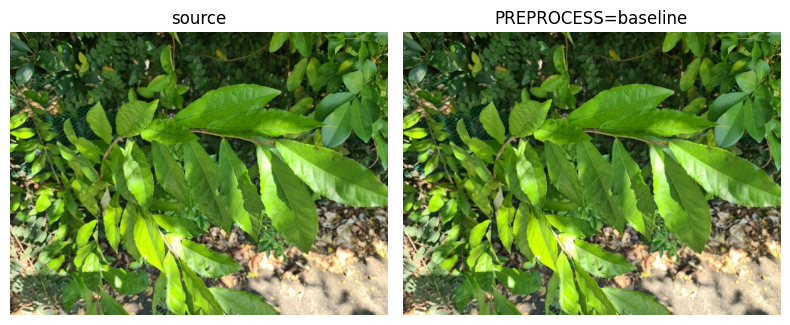

In [9]:
import matplotlib.pyplot as plt
_pre = CesarPreprocess(mode=PREPROCESS, downscale=SOURCE_DOWNSCALE)
_p = samples[0][0]
_orig = Image.open(_p).convert('RGB')
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(_orig); ax[0].set_title('source'); ax[0].axis('off')
ax[1].imshow(_pre(_orig)); ax[1].set_title(f'PREPROCESS={PREPROCESS}'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## Build ViT + matching transforms, then train

In [10]:
import os, sys
MODEL_NAME = MODEL_NAMES[0]
_ckpt = os.path.join(CKPT_DIR, f'{MODEL_NAME}_{RUN_TAG}_ckpt.pt')
_resuming = RESUME and os.path.exists(_ckpt)
# On resume the checkpoint already holds ALL weights, so skip the flaky/slow
# HuggingFace pretrained download entirely (this was the stall point on background runs).
print(f'creating {MODEL_NAME} (pretrained={not _resuming}, resuming={_resuming}) ...', flush=True)
model = timm.create_model(MODEL_NAME, pretrained=not _resuming, num_classes=NUM_CLASSES)
print('model ready', flush=True)
dc = resolve_model_data_config(model); dc['input_size'] = (3, INPUT_SIZE, INPUT_SIZE)
print('mean/std', dc['mean'], dc['std'], '| params', f"{sum(p.numel() for p in model.parameters()):,}")
train_tf, eval_tf = build_transforms(dc, PREPROCESS, SOURCE_DOWNSCALE)

cfg = dict(device=device, batch=BATCH_SIZE, workers=NUM_WORKERS, balanced=BALANCED_SAMPLER,
           lr=LR, wd=WEIGHT_DECAY, warmup_ep=WARMUP_EPOCHS, epochs=EPOCHS,
           label_smooth=LABEL_SMOOTHING, amp=USE_AMP, topk=TOPK, patience=PATIENCE,
           resume=RESUME, ckpt_dir=CKPT_DIR, run_tag=RUN_TAG, seed=SEED)

print('=' * 60); print(f'{MODEL_NAME}  [{RUN_TAG}]'); print('=' * 60)
res = train_one(model, MODEL_NAME, train_s, val_s, train_tf, eval_tf, cfg)
best_acc = res['best_acc']
print(f'\nBEST validation Top-1 = {best_acc:.4f}  (used for model selection / early stopping)')

# ---- held-out TEST evaluation: these are the numbers reported in the paper ----
test_loader = make_eval_loader(test_s, eval_tf, BATCH_SIZE, NUM_WORKERS)
res['test'] = evaluate(res['model'], test_loader, TOPK, device, USE_AMP)
t = res['test']
kmsg = '  '.join(f'top{k}={t["accs"][k]:.4f}' for k in TOPK)
print(f'TEST  {kmsg}  macroF1={t["macro_f1"]:.4f}  weightedF1={t["weighted_f1"]:.4f}  (n={t["n"]})')
print(f'train wall-clock: {res.get("runtime_s", 0) / 60:.1f} min')
print(f'\n>>> paste into Notebook 2:  VIT_CEILING = {t["accs"][1]:.4f}   '
      f'(TEST top-1, preprocess={RUN_TAG})')

# uniform container so the results-dump cell works for both notebooks
_results_vit = {MODEL_NAME: res}


creating vit_base_patch16_224 (pretrained=False, resuming=True) ...
model ready
mean/std (0.5, 0.5, 0.5) (0.5, 0.5, 0.5) | params 87,891,105
vit_base_patch16_224  [baseline]
  building dataloaders (workers=2) ...
  dataloaders ready
resumed vit_base_patch16_224 from epoch 18 (best Top-1=0.809, patience=0)
  entering training loop at epoch 19/30 ...
  epoch 19/30  loss=1.467  top1=0.814  top5=0.922  top10=0.944  (2650s/ep, ETA 486m)  *best*
  epoch 20/30  loss=1.444  top1=0.819  top5=0.925  top10=0.945  (2154s/ep, ETA 359m)  *best*
  epoch 21/30  loss=1.427  top1=0.825  top5=0.928  top10=0.947  (2158s/ep, ETA 324m)  *best*
  epoch 22/30  loss=1.410  top1=0.828  top5=0.929  top10=0.949  (2157s/ep, ETA 288m)  *best*
  epoch 23/30  loss=1.400  top1=0.829  top5=0.930  top10=0.949  (2166s/ep, ETA 253m)  *best*
  epoch 24/30  loss=1.383  top1=0.832  top5=0.931  top10=0.950  (2157s/ep, ETA 216m)  *best*
  epoch 25/30  loss=1.374  top1=0.835  top5=0.932  top10=0.951  (2156s/ep, ETA 180m)  *best

## Save teacher (+ optional soft labels)

In [11]:
m = res['model']
torch.save(m.state_dict(), f'{CKPT_DIR}/vit_b16_teacher_{RUN_TAG}.pt')
print(f'saved vit_b16_teacher_{RUN_TAG}.pt | ceiling Top-1:', round(best_acc, 3))

if EXPORT_SOFT_LABELS:
    dl = DataLoader(PlantDS(samples, eval_tf), batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
    m = m.to(device).eval(); logits = []
    with torch.no_grad(), autocast('cuda', enabled=USE_AMP, dtype=torch.float16):
        for x, _ in dl: logits.append(m(x.to(device)).float().cpu().half().numpy())
    np.save(f'{CKPT_DIR}/vit_teacher_logits_fp16_{RUN_TAG}.npy', np.concatenate(logits))
    np.save(f'{CKPT_DIR}/vit_teacher_files_{RUN_TAG}.npy', np.array([p for p, _ in samples]))
    print('exported soft labels (fp16)')

saved vit_b16_teacher_baseline.pt | ceiling Top-1: 0.839


### Next\nPaste this best Top-1 into Notebook 2's `VIT_CEILING` and run Notebook 2 on the **same** `DATA_DIR` and **same `PREPROCESS`**. For the sweep, run once per mode, pairing each ceiling with the matching Notebook 2 run.

## Persist results (JSON + CSV) for manuscript tables/figures

Writes `results_<run_tag>.json` (one self-describing record per model) and relies on the per-epoch `*_history.csv` files saved during training. Re-run this per `PREPROCESS` mode / seed; the JSON filename is tagged so runs don't overwrite each other. Attach these files as the notebook output to regenerate tables and curves without retraining.

In [ ]:
# ---- persist machine-readable results for the manuscript ----
# Writes results_<run_tag>.json (one record per model) so tables/figures can be
# regenerated later WITHOUT re-running training. Per-epoch curves are in the
# *_history.csv files written during training.
import json, os, glob, platform, torch

def _record(name, r):
    t = r.get('test', {})
    return {
        'model': name,
        'run_tag': RUN_TAG,
        'preprocess': PREPROCESS,
        'seed': SEED,
        'num_classes': NUM_CLASSES,
        'min_images_per_class': MIN_IMAGES_PER_CLASS,
        'split': {'train': len(train_s), 'val': len(val_s), 'test': len(test_s),
                  'val_frac': VAL_SPLIT, 'test_frac': TEST_SPLIT},
        'params': r.get('params'),
        'val_top1_best': r.get('best_acc'),
        'test': {
            'n': t.get('n'),
            **{f'top{k}': t.get('accs', {}).get(k) for k in TOPK},
            'macro_f1': t.get('macro_f1'),
            'weighted_f1': t.get('weighted_f1'),
        },
        'tflite_fp16_mb': r.get('tflite_fp16_mb'),
        'tflite_fp32_mb': r.get('tflite_fp32_mb'),
        'parity_top1_ok': r.get('parity_top1_ok'),
        'train_runtime_s': r.get('runtime_s'),
        'history_csv': f'{name}_{RUN_TAG}_history.csv',
        'env': {'torch': torch.__version__,
                'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu',
                'python': platform.python_version()},
    }

records = {name: _record(name, r) for name, r in _results_vit.items()}
# distinct filename so this NEVER clobbers Notebook 2's results_<tag>.json, and does
# not match the aggregator's results_*_s*.json glob (ViT stays out of the mobile table).
out_path = os.path.join(CKPT_DIR, f'vit_results_{RUN_TAG}.json')
with open(out_path, 'w') as f:
    json.dump(records, f, indent=2)

# tiny ceiling file Notebook 2 auto-reads for its reference line
_vit_top1 = records[MODEL_NAME]['test']['top1']
ceiling_path = os.path.join(CKPT_DIR, f'vit_ceiling_{RUN_TAG}.json')
with open(ceiling_path, 'w') as f:
    json.dump({'run_tag': RUN_TAG, 'preprocess': PREPROCESS, 'seed': SEED,
               'vit_model': MODEL_NAME, 'vit_ceiling_top1': _vit_top1}, f, indent=2)

print('wrote', out_path)
print('wrote', ceiling_path, '| ViT ceiling top1:', round(_vit_top1, 4))
print('history csv files:', sorted(os.path.basename(p) for p in glob.glob(os.path.join(CKPT_DIR, '*_history.csv'))))
print(json.dumps(records, indent=2)[:1500])
